# Normalized Attention Guidance

paper: https://arxiv.org/abs/2505.21179

project page: https://chendaryen.github.io/NAG.github.io/

Hugging Face Demo: https://huggingface.co/spaces/ChenDY/NAG_FLUX.1-schnell and https://huggingface.co/spaces/ChenDY/NAG_FLUX.1-dev

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [2]:
import torch
from PIL import Image

from nag import NAGFluxPipeline
from nag import NAGFluxTransformer2DModel

/home/wg25r/miniconda/envs/py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# load pipeline
model_id = "black-forest-labs/FLUX.1-schnell" 
# model_id = "black-forest-labs/FLUX.1-dev" 
# model_id = "weathon/dance_flux",
transformer = NAGFluxTransformer2DModel.from_pretrained(
    model_id,
    subfolder="transformer",
    torch_dtype=torch.bfloat16,
)
pipe = NAGFluxPipeline.from_pretrained(
    model_id,
    transformer=transformer,
    torch_dtype=torch.bfloat16,
)

device="cuda"
pipe = pipe.to(device)

Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  6.81it/s]


## Sampling with NAG

In [4]:
prompt = "a laptop computer on a wooden table, in a cozy cafe, with a cup of coffee, by the window, during sunset, with warm lighting" 
nag_negative_prompt = "touchpad"
num_inference_steps = 28
nag_scale = 7.0
nag_alpha = 0.5
seed = 2047

In [5]:
# sampling

image_baseline = pipe(
    prompt,
    guidance_scale=4.5,
    nag_scale=0.,
    generator=torch.Generator(device="cuda").manual_seed(seed),
    num_inference_steps=num_inference_steps,
    max_sequence_length=256,
).images[0]

image_nag = pipe(
    prompt,
    guidance_scale=4.5,
    nag_negative_prompt=nag_negative_prompt,
    nag_scale=nag_scale,
    generator=torch.Generator(device="cuda").manual_seed(seed),
    num_inference_steps=num_inference_steps,
    nag_alpha=nag_alpha,
    max_sequence_length=256,
).images[0]

100%|██████████| 28/28 [01:01<00:00,  2.21s/it]


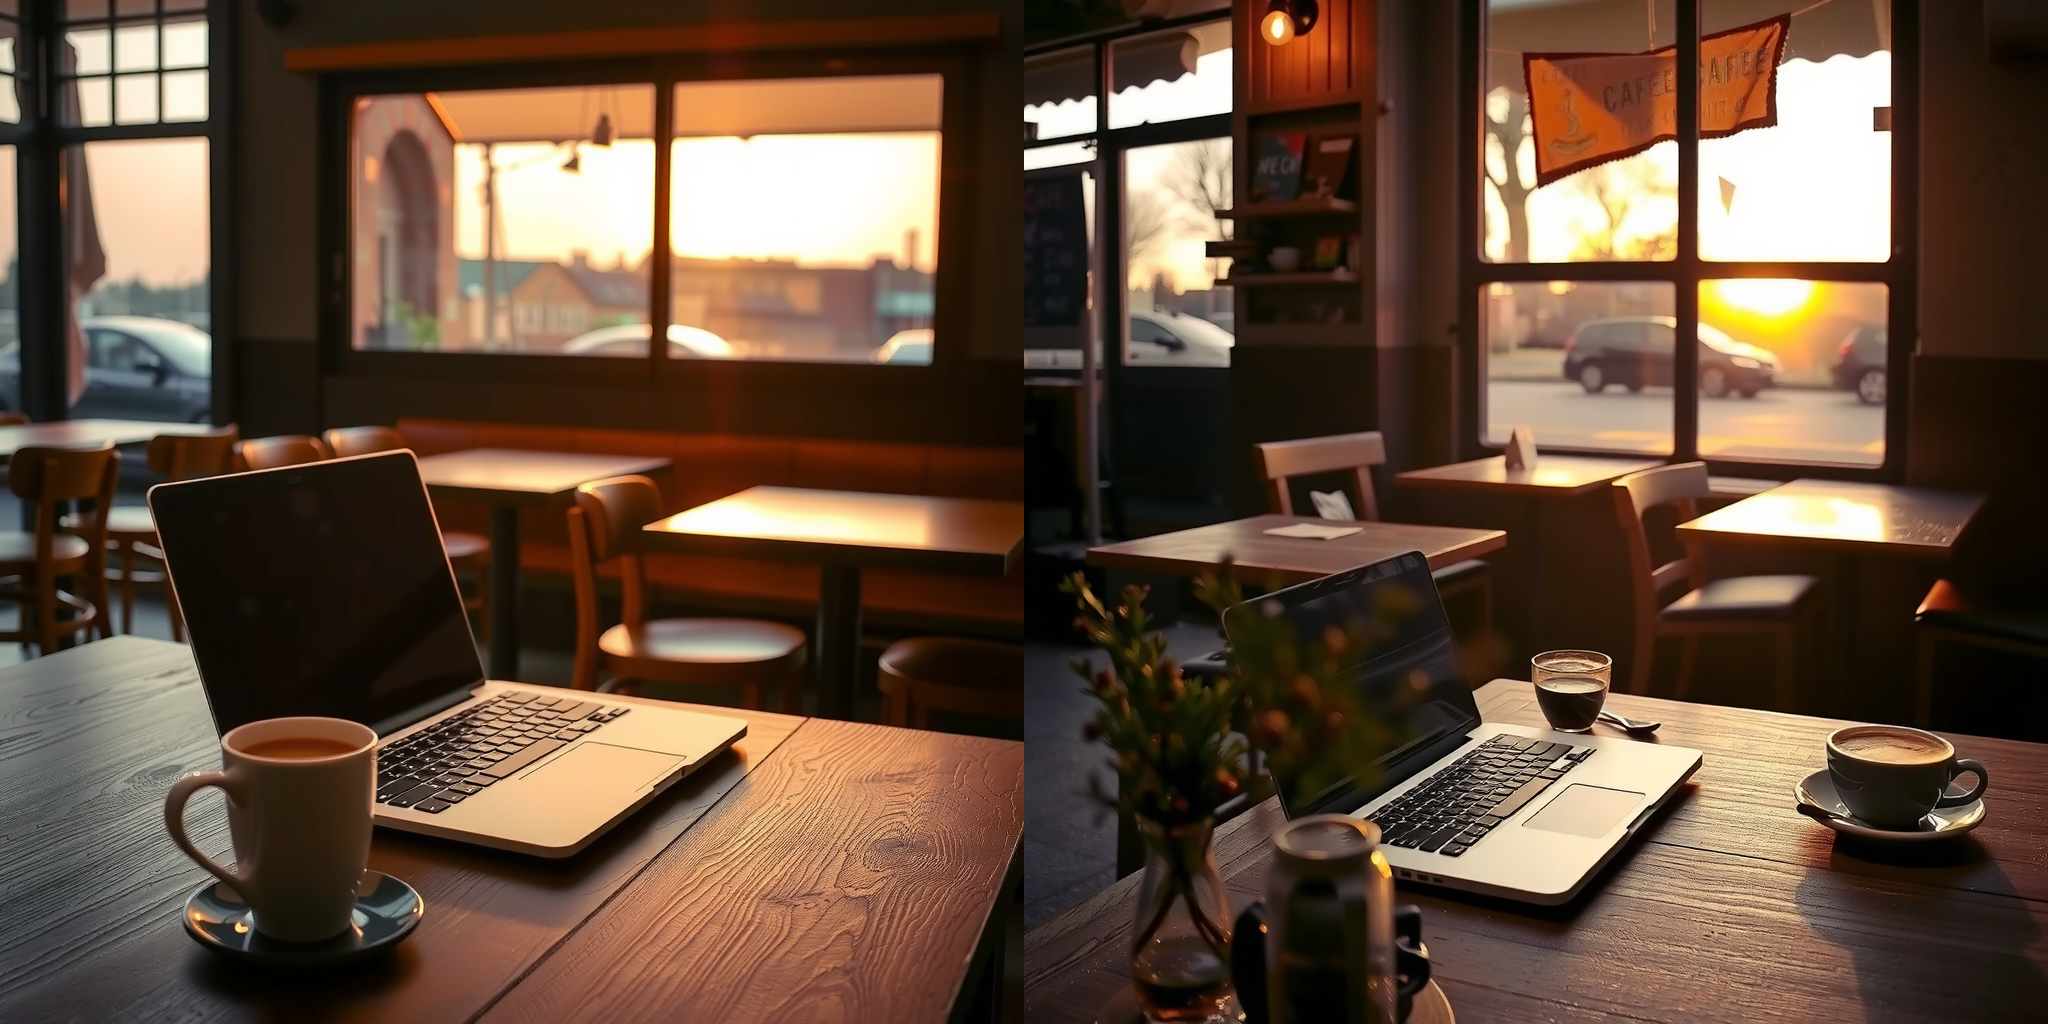

In [6]:
image_compare = Image.new('RGB', (2048, 1024))
image_compare.paste(image_baseline, (0, 0))
image_compare.paste(image_nag, (1024, 0))
image_compare